# 1 Duration

- 10 years to maturity

- coupon rate of 3%

- yield to maturity (semiannual) is 5%



## 1.1 

In [7]:

def duration(y, c, n, tau):
    y_adjusted = y / n
    c_adjusted = c / n
    tau_adjusted = tau * n
    duration = (1 / n) * ((1 + y_adjusted) / y_adjusted - (1 + y_adjusted + tau_adjusted * (c_adjusted - y_adjusted)) / (c_adjusted * ((1 + y_adjusted) ** tau_adjusted - 1) + y_adjusted))
    return duration


print(f"Duration of the bond: {duration(y=0.05, c=0.03, n=2, tau=10):.4f} years")

Duration of the bond: 8.5709 years


## 1.2 C =7%

In [8]:
print(f"Duration of the bond: {duration(y=0.05, c=0.07, n=2, tau=10):.4f} years")

Duration of the bond: 7.5648 years


## 1.3 C = 5%

In [9]:
print(f"Duration of the bond: {duration(y=0.05, c=0.05, n=2, tau=10):.4f} years")

Duration of the bond: 7.9894 years


## 1.4
- As the coupon rate increase, the duration decreases since more cash arrives sooner

# 2 Hedging Duration

## 2.1

In [15]:
import pandas as pd

filepath = "../Data/treasury_ts_duration_2025-05-30.xlsx"

SHEET_CLEAN = 'clean price'
SHEET_DIRTY = 'dirty price'
SHEET_DURATION = 'duration'
INDEX_NAME = 'quote date'

clean = pd.read_excel(filepath,sheet_name=SHEET_CLEAN).set_index(INDEX_NAME)
dirty = pd.read_excel(filepath,sheet_name=SHEET_DIRTY).set_index(INDEX_NAME)
duration = pd.read_excel(filepath,sheet_name=SHEET_DURATION).set_index(INDEX_NAME)
display(dirty.head())
display(duration.head())

,207391,207392
quote date,,
2019-08-09,98.882812,99.789062
2019-08-12,99.796875,102.554688
2019-08-13,99.281250,101.867188
2019-08-14,100.406250,105.179688
2019-08-15,100.882812,106.234375


,207391,207392
quote date,,
2019-08-09,9.289497,22.000102
2019-08-12,9.285468,22.118496
2019-08-13,9.280314,22.084308
2019-08-14,9.282750,22.228549
2019-08-15,9.282163,22.270910


In [48]:
first_duration = duration.iloc[1,:]
print(first_duration)
short_position = float(first_duration.loc[207391]) * 10000 / first_duration.loc[207392]
print(f"short_position: {short_position}")

207391     9.285468
207392    22.118496
Name: 2019-08-12 00:00:00, dtype: float64
short_position: 4198.055834780657


## 2.2 

In [34]:
print(len(dirty))
print(len(duration))

1454
1454


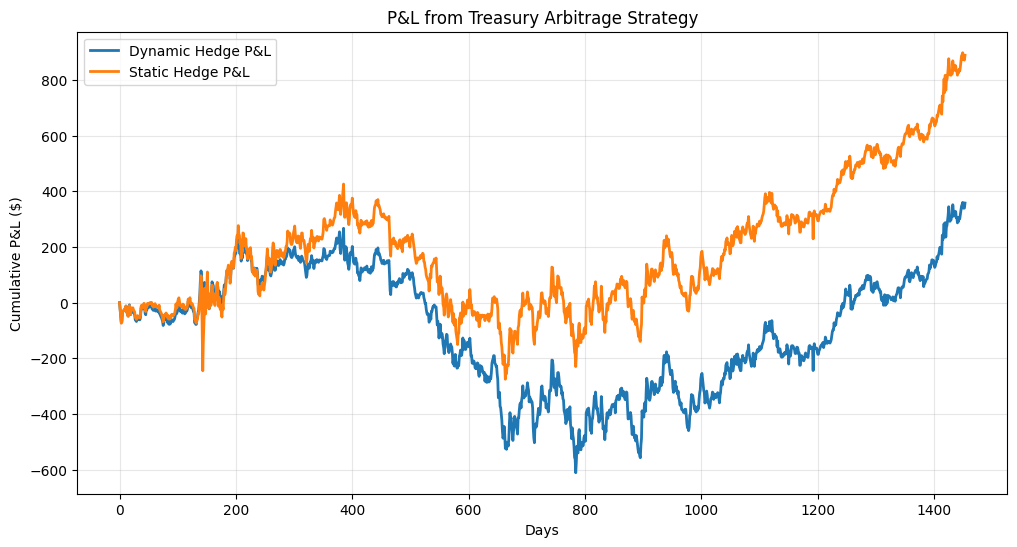

Final Dynamic Hedge P&L: $357.51
Final Static Hedge P&L: $888.55


In [50]:
long_dollar = 10000
dynamic_pnl = 0
dynamic_pnl_list = []
static_pnl = 0
static_pnl_list = []

# Initial setup
initial_long_price = dirty.iloc[0, :].loc[207391]
num_long_bonds = long_dollar / initial_long_price  # Fixed number of long bonds

static_short_dollar = float(duration.iloc[0, :].loc[207391]) * long_dollar / duration.iloc[0, :].loc[207392]
initial_short_price = dirty.iloc[0, :].loc[207392]
num_short_bonds_static = static_short_dollar / initial_short_price  # Fixed for static hedge

for i in range(len(dirty)):
    long_price = dirty.iloc[i, :].loc[207391]
    short_price = dirty.iloc[i, :].loc[207392]
    
    if i == 0:
        dynamic_pnl_list.append(0)
        static_pnl_list.append(0)
    else:
        prev_long_price = dirty.iloc[i-1, :].loc[207391]
        prev_short_price = dirty.iloc[i-1, :].loc[207392]
        
        # Dynamic hedge: recalculate short position based on PREVIOUS day's values
        long_value_prev = num_long_bonds * prev_long_price
        short_dollar_dynamic = float(duration.iloc[i-1, :].loc[207391]) * long_value_prev / duration.iloc[i-1, :].loc[207392]
        num_short_bonds_dynamic = short_dollar_dynamic / prev_short_price
        
        # Calculate daily P&L using fixed number of bonds
        new_dynamic_pnl = (num_long_bonds * (long_price - prev_long_price) - 
                          num_short_bonds_dynamic * (short_price - prev_short_price))
        dynamic_pnl += new_dynamic_pnl
        dynamic_pnl_list.append(dynamic_pnl)
        
        # Static hedge P&L
        new_static_pnl = (num_long_bonds * (long_price - prev_long_price) - 
                         num_short_bonds_static * (short_price - prev_short_price))
        static_pnl += new_static_pnl
        static_pnl_list.append(static_pnl)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(dynamic_pnl_list, label="Dynamic Hedge P&L", linewidth=2)
plt.plot(static_pnl_list, label="Static Hedge P&L", linewidth=2)
plt.title("P&L from Treasury Arbitrage Strategy")
plt.xlabel("Days")
plt.ylabel("Cumulative P&L ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Dynamic Hedge P&L: ${dynamic_pnl:,.2f}")
print(f"Final Static Hedge P&L: ${static_pnl:,.2f}")